# 🇮🇩 IndoBERT Fine-Tuning Pipeline
> Binary Text Classification — Dataset sudah melalui preprocessing, augmentasi, normalisasi & split

**Dataset Info:**
- Train: 1500 label 0 + 1500 label 1 = **3000 sampel**
- Validation: 200 label 0 + 78 label 1 = **278 sampel**
- Test: 300 label 0 + 300 label 1 = **600 sampel**

## 1. 📦 Import Library

In [1]:
# ── Core ──────────────────────────────────────────────────────────────────────
import os
import random
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
from torch.utils.data import Dataset, DataLoader

# ── HuggingFace ───────────────────────────────────────────────────────────────
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed,
)
from datasets import load_dataset, DatasetDict, ClassLabel

# ── Metrics ───────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('✅ Semua library berhasil diimport!')
print(f'   PyTorch      : {torch.__version__}')
import transformers
print(f'   Transformers : {transformers.__version__}')
print(f'   Pandas       : {pd.__version__}')
print(f'   NumPy        : {np.__version__}')

✅ Semua library berhasil diimport!
   PyTorch      : 2.10.0+cu128
   Transformers : 5.0.0
   Pandas       : 2.3.3
   NumPy        : 2.0.2


## 2. ⚡ Cek GPU

In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    gpu_name  = torch.cuda.get_device_name(0)
    gpu_total = torch.cuda.get_device_properties(0).total_memory / 1e9
    gpu_free  = (torch.cuda.get_device_properties(0).total_memory
                 - torch.cuda.memory_allocated(0)) / 1e9
    print('🟢 GPU tersedia!')
    print(f'   Nama GPU    : {gpu_name}')
    print(f'   Total VRAM  : {gpu_total:.2f} GB')
    print(f'   VRAM Bebas  : {gpu_free:.2f} GB')
    print(f'   CUDA Version: {torch.version.cuda}')
else:
    device = torch.device('cpu')
    print('🔴 GPU tidak tersedia — menggunakan CPU')
    print('   Tips: Kaggle → Settings → Accelerator → GPU T4 x2')

print(f'\n   Device aktif : {device}')

🟢 GPU tersedia!
   Nama GPU    : Tesla T4
   Total VRAM  : 15.64 GB
   VRAM Bebas  : 15.64 GB
   CUDA Version: 12.8

   Device aktif : cuda


## 3. 📂 Path Dataset

In [3]:
# ── Sesuaikan path ini dengan lokasi file CSV kamu di Kaggle ──────────────────
BASE_PATH  = '/kaggle/input/datasets/ricky131/dataset-indobert'   # ← ganti sesuai nama dataset

TRAIN_PATH = os.path.join(BASE_PATH, 'train_balanced_metadata.csv')
VAL_PATH   = os.path.join(BASE_PATH, 'val_pure_metadata.csv')
TEST_PATH  = os.path.join(BASE_PATH, 'test_pure_metadata.csv')

# ── Output ────────────────────────────────────────────────────────────────────
OUTPUT_DIR    = '/kaggle/working/indobert-output'
LOGGING_DIR   = '/kaggle/working/logs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOGGING_DIR, exist_ok=True)

# ── Validasi file ada ─────────────────────────────────────────────────────────
for name, path in [('Train', TRAIN_PATH), ('Val', VAL_PATH), ('Test', TEST_PATH)]:
    exists = os.path.exists(path)
    icon   = '✅' if exists else '❌'
    print(f'  {icon}  {name:5s} : {path}')

print(f'\n  📁 Output dir : {OUTPUT_DIR}')

  ✅  Train : /kaggle/input/datasets/ricky131/dataset-indobert/train_balanced_metadata.csv
  ✅  Val   : /kaggle/input/datasets/ricky131/dataset-indobert/val_pure_metadata.csv
  ✅  Test  : /kaggle/input/datasets/ricky131/dataset-indobert/test_pure_metadata.csv

  📁 Output dir : /kaggle/working/indobert-output


## 4. 📖 Load Dataset

In [4]:
# ── Kolom yang dipakai: label & data_clean ────────────────────────────────────
COLS = ['label', 'data_clean']

df_train = pd.read_csv(TRAIN_PATH, usecols=COLS)
df_val   = pd.read_csv(VAL_PATH,   usecols=COLS)
df_test  = pd.read_csv(TEST_PATH,  usecols=COLS)

# Pastikan tipe data label integer
for df in [df_train, df_val, df_test]:
    df['label'] = df['label'].astype(int)

print('╔══════════════════════════════════════════╗')
print('║         INFO DATASET (ringkas)           ║')
print('╠══════════════════════════════════════════╣')
print(f'║  Train   : {len(df_train):>5} baris                  ║')
print(f'║  Val     : {len(df_val):>5} baris                  ║')
print(f'║  Test    : {len(df_test):>5} baris                  ║')
print(f'║  Total   : {len(df_train)+len(df_val)+len(df_test):>5} baris                  ║')
print('╚══════════════════════════════════════════╝')

# ── Preview Train ─────────────────────────────────────────────────────────────
print('\n🔎 5 Data Pertama — TRAIN:')
display(df_train.head())

print('\n🔎 5 Data Pertama — VAL:')
display(df_val.head())

print('\n🔎 5 Data Pertama — TEST:')
display(df_test.head())

# ── Info & Missing Values ─────────────────────────────────────────────────────
print('\n📊 Missing Values:')
for name, df in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    print(f'  {name}: {df.isnull().sum().to_dict()}')

╔══════════════════════════════════════════╗
║         INFO DATASET (ringkas)           ║
╠══════════════════════════════════════════╣
║  Train   :  3000 baris                  ║
║  Val     :   278 baris                  ║
║  Test    :   600 baris                  ║
║  Total   :  3878 baris                  ║
╚══════════════════════════════════════════╝

🔎 5 Data Pertama — TRAIN:


,label,data_clean
0,0,"anthony albanese, pm australia yang menangis g..."
1,1,zeus4d: situs slot gacor gampang sensasional h...
2,1,promosi dan hadiah terbaik koitoto daftar bers...
3,0,"video: rusia tembak laut jepang, perang meleba..."
4,0,kemendagri dan sejumlah lsm audiensi terkait p...



🔎 5 Data Pertama — VAL:


,label,data_clean
0,1,messipoker adalah situs gacor mitra hkb gaming...
1,0,digiasia bios umumkan strategi bisnis terbarun...
2,0,"4 anggota kkb tewas, mahfud: tembagapura sepen..."
3,0,"viral pencurian lampu-gagang pintu di medan, p..."
4,0,gibran mendadak temui ganjar pranowo di semara...



🔎 5 Data Pertama — TEST:


,label,data_clean
0,1,situs rtp lingtogel77 - rtp slot gacor hari in...
1,0,"'indonesia terserah' viral gara-gara corona, t..."
2,0,"tembus ke bawah rp 14.900/us$, rupiah jadi lia..."
3,1,"home - vingaming want to be our partners? ""tak..."
4,1,nagahoki88: situs bandar judi resmi live casin...



📊 Missing Values:
  Train: {'label': 0, 'data_clean': 0}
  Val: {'label': 0, 'data_clean': 0}
  Test: {'label': 0, 'data_clean': 0}


In [5]:
# ── Statistik panjang teks ────────────────────────────────────────────────────
print('📏 Statistik Panjang Teks (karakter):')
for name, df in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    lengths = df['data_clean'].str.len()
    print(f'  {name:5s} → min={lengths.min()}, max={lengths.max()}, '
          f'mean={lengths.mean():.1f}, median={lengths.median():.1f}')

📏 Statistik Panjang Teks (karakter):
  Train → min=36, max=49847, mean=1890.4, median=1338.0
  Val   → min=17, max=20004, mean=2122.4, median=1454.5
  Test  → min=31, max=49304, mean=2070.8, median=1385.5


## 5. 📊 Distribusi Dataset Per Label & Per Split

📋 Tabel Distribusi Dataset:


Split,Train,Val,Test
Label,,,
Label 0,1500,200,300
Label 1,1500,78,300


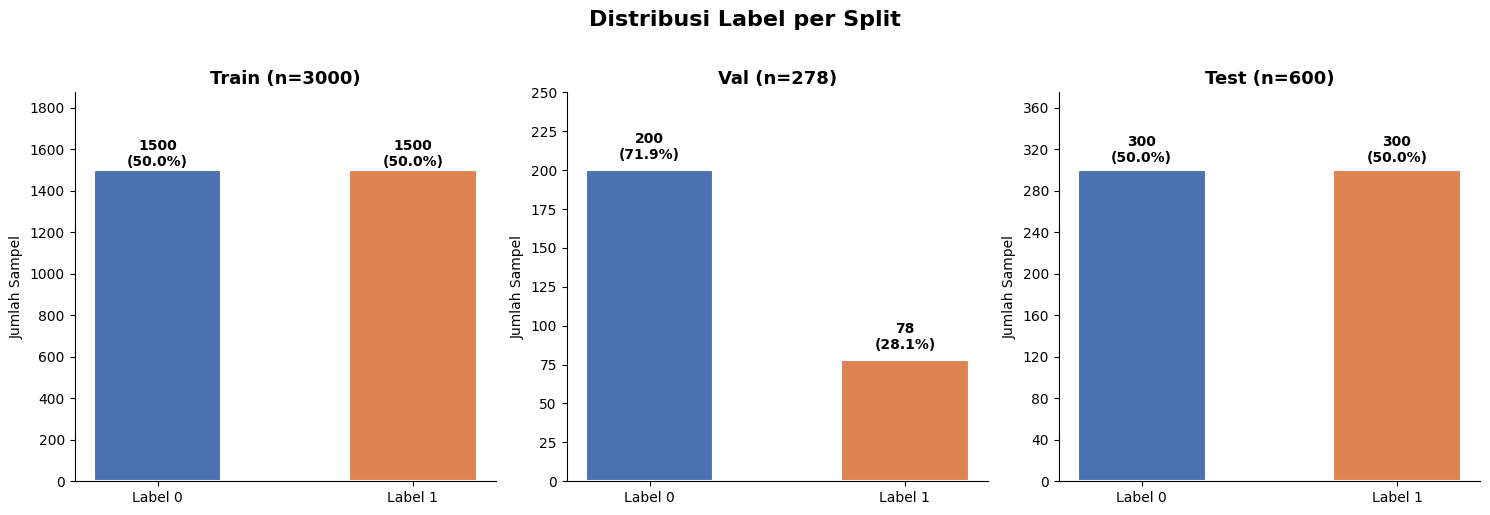

✅ Grafik disimpan!


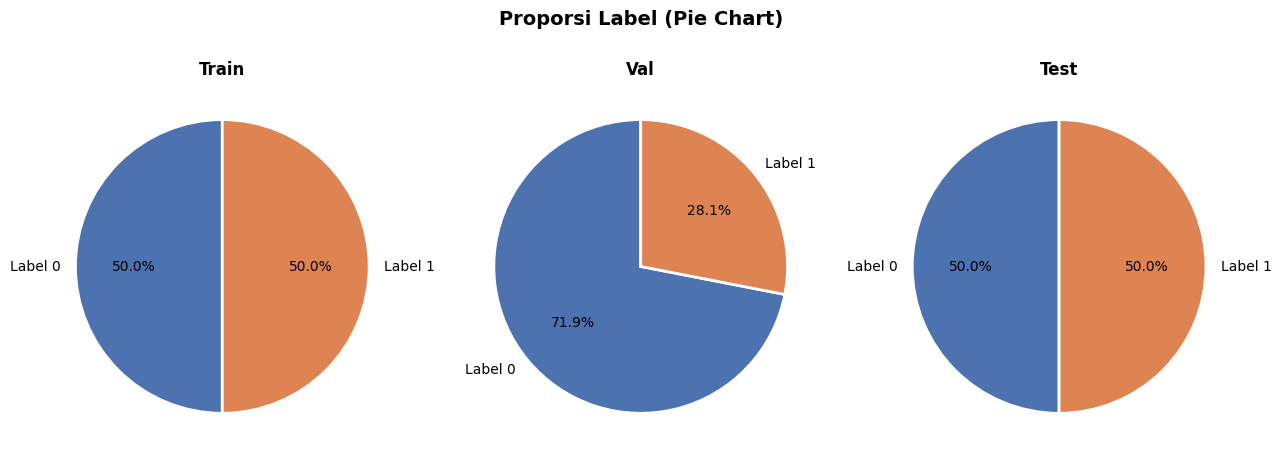

⚠️  Catatan: Validation set IMBALANCED (ratio 2.56:1) → akan dihandle dengan class_weight di loss function


In [6]:
# ── Tabel distribusi ──────────────────────────────────────────────────────────
splits = {'Train': df_train, 'Val': df_val, 'Test': df_test}

rows = []
for split_name, df in splits.items():
    counts = df['label'].value_counts().sort_index()
    total  = len(df)
    for label, cnt in counts.items():
        rows.append({
            'Split'  : split_name,
            'Label'  : f'Label {label}',
            'Jumlah' : cnt,
            'Persen' : f'{cnt/total*100:.1f}%'
        })

dist_df = pd.DataFrame(rows)
print('📋 Tabel Distribusi Dataset:')
display(dist_df.pivot_table(index='Label', columns='Split',
                            values='Jumlah', aggfunc='sum')
                .reindex(columns=['Train', 'Val', 'Test']))

# ── Visualisasi ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribusi Label per Split', fontsize=16, fontweight='bold', y=1.02)

COLORS = ['#4C72B0', '#DD8452']

for ax, (split_name, df) in zip(axes, splits.items()):
    counts = df['label'].value_counts().sort_index()
    bars   = ax.bar([f'Label {i}' for i in counts.index],
                    counts.values, color=COLORS, width=0.5, edgecolor='white', linewidth=1.5)
    # Anotasi jumlah
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 5,
                f'{val}\n({val/len(df)*100:.1f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(f'{split_name} (n={len(df)})', fontsize=13, fontweight='bold')
    ax.set_ylabel('Jumlah Sampel')
    ax.set_ylim(0, counts.max() * 1.25)
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/distribusi_label.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik disimpan!')

# ── Pie chart imbalance check (val) ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle('Proporsi Label (Pie Chart)', fontsize=14, fontweight='bold')
for ax, (split_name, df) in zip(axes, splits.items()):
    counts = df['label'].value_counts().sort_index()
    ax.pie(counts.values, labels=[f'Label {i}' for i in counts.index],
           colors=COLORS, autopct='%1.1f%%', startangle=90,
           wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    ax.set_title(f'{split_name}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/pie_distribusi.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Catatan imbalance ─────────────────────────────────────────────────────────
val_counts = df_val['label'].value_counts().sort_index()
ratio = val_counts.max() / val_counts.min()
print(f'⚠️  Catatan: Validation set IMBALANCED (ratio {ratio:.2f}:1) → '
      'akan dihandle dengan class_weight di loss function')

## 6. 🔧 Konfigurasi Model

In [7]:
# ── Pilih model IndoBERT ───────────────────────────────────────────────────────
# Opsi:
#   'indobenchmark/indobert-base-p1'  ← IndoBERT Base (rekomendasi)
#   'indobenchmark/indobert-large-p1' ← IndoBERT Large (butuh VRAM lebih besar)
#   'indolem/indobert-base-uncased'   ← alternatif
MODEL_NAME   = 'indobenchmark/indobert-base-p1'
NUM_LABELS   = 2
MAX_LEN      = 512    # sesuaikan jika teks panjang (maks 512)
BATCH_SIZE   = 32     # turunkan ke 16 jika OOM
EPOCHS       = 50
LR           = 1e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1

print('⚙️  Konfigurasi Training:')
print(f'   Model       : {MODEL_NAME}')
print(f'   Num Labels  : {NUM_LABELS}')
print(f'   Max Length  : {MAX_LEN}')
print(f'   Batch Size  : {BATCH_SIZE}')
print(f'   Epochs      : {EPOCHS}')
print(f'   Learning Rate: {LR}')
print(f'   Weight Decay: {WEIGHT_DECAY}')
print(f'   Warmup Ratio: {WARMUP_RATIO}')

⚙️  Konfigurasi Training:
   Model       : indobenchmark/indobert-base-p1
   Num Labels  : 2
   Max Length  : 512
   Batch Size  : 32
   Epochs      : 50
   Learning Rate: 1e-05
   Weight Decay: 0.01
   Warmup Ratio: 0.1


## 7. 🔤 Load Tokenizer

In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f'✅ Tokenizer berhasil dimuat: {MODEL_NAME}')
print(f'   Vocab size : {tokenizer.vocab_size:,}')

# ── Contoh tokenisasi ─────────────────────────────────────────────────────────
sample_text = df_train['data_clean'].iloc[0]
sample_enc  = tokenizer(sample_text, max_length=MAX_LEN,
                        truncation=True, padding='max_length')
print(f'\n🔍 Contoh tokenisasi (baris pertama train):')
print(f'   Teks     : {sample_text[:80]}...')
print(f'   Input IDs: {sample_enc["input_ids"][:10]} ... ({len(sample_enc["input_ids"])} token)')

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ Tokenizer berhasil dimuat: indobenchmark/indobert-base-p1
   Vocab size : 30,521

🔍 Contoh tokenisasi (baris pertama train):
   Teks     : anthony albanese, pm australia yang menangis gegara aborigin ini menyangkut peng...
   Input IDs: [2, 25815, 13231, 5128, 30357, 30468, 2419, 4951, 34, 5869] ... (512 token)


## 8. 🗂️ Buat PyTorch Dataset

In [9]:
class TextDataset(Dataset):
    """PyTorch Dataset untuk IndoBERT fine-tuning."""

    def __init__(self, dataframe: pd.DataFrame, tokenizer, max_len: int):
        self.texts     = dataframe['data_clean'].tolist()
        self.labels    = dataframe['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length      = self.max_len,
            padding         = 'max_length',
            truncation      = True,
            return_tensors  = 'pt',
        )
        return {
            'input_ids'      : enc['input_ids'].squeeze(0),
            'attention_mask' : enc['attention_mask'].squeeze(0),
            'labels'         : torch.tensor(self.labels[idx], dtype=torch.long),
        }


train_dataset = TextDataset(df_train, tokenizer, MAX_LEN)
val_dataset   = TextDataset(df_val,   tokenizer, MAX_LEN)
test_dataset  = TextDataset(df_test,  tokenizer, MAX_LEN)

print(f'✅ Dataset siap:')
print(f'   Train   : {len(train_dataset)} sampel')
print(f'   Val     : {len(val_dataset)} sampel')
print(f'   Test    : {len(test_dataset)} sampel')

# Cek satu item
sample_item = train_dataset[0]
print(f'\n🔍 Bentuk tensor satu item:')
for k, v in sample_item.items():
    print(f'   {k:15s}: shape={v.shape}, dtype={v.dtype}')

✅ Dataset siap:
   Train   : 3000 sampel
   Val     : 278 sampel
   Test    : 600 sampel

🔍 Bentuk tensor satu item:
   input_ids      : shape=torch.Size([512]), dtype=torch.int64
   attention_mask : shape=torch.Size([512]), dtype=torch.int64
   labels         : shape=torch.Size([]), dtype=torch.int64


## 9. ⚖️ Hitung Class Weight (Imbalance Val)

In [10]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.array([0, 1]),
    y            = df_train['label'].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print(f'⚖️  Class Weights (dari data train):')
print(f'   Label 0 : {class_weights[0]:.4f}')
print(f'   Label 1 : {class_weights[1]:.4f}')
print('   (Train sudah seimbang → weight ≈ 1.0, wajar)')

⚖️  Class Weights (dari data train):
   Label 0 : 1.0000
   Label 1 : 1.0000
   (Train sudah seimbang → weight ≈ 1.0, wajar)


## 10. 🤖 Load Model IndoBERT

In [11]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels            = NUM_LABELS,
    id2label              = {0: 'Negatif', 1: 'Positif'},  # ← sesuaikan label
    label2id              = {'Negatif': 0, 'Positif': 1},
    hidden_dropout_prob   = 0.1,
    attention_probs_dropout_prob = 0.1,
)
model.to(device)

total_params   = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'✅ Model berhasil dimuat: {MODEL_NAME}')
print(f'   Total Parameter    : {total_params:,}')
print(f'   Trainable Parameter: {trainable_params:,}')
print(f'   Device             : {next(model.parameters()).device}')

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

✅ Model berhasil dimuat: indobenchmark/indobert-base-p1
   Total Parameter    : 124,442,882
   Trainable Parameter: 124,442,882
   Device             : cuda:0


## 11. 📐 Custom Trainer dengan Weighted Loss

In [12]:
import torch.nn as nn

class WeightedTrainer(Trainer):
    """Trainer dengan weighted cross-entropy untuk imbalance dataset."""

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        logits  = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)
        loss    = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss


print('✅ WeightedTrainer siap digunakan.')

✅ WeightedTrainer siap digunakan.


## 12. 📏 Fungsi Compute Metrics

In [13]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy'  : accuracy_score(labels, preds),
        'f1_macro'  : f1_score(labels, preds, average='macro'),
        'f1_weighted': f1_score(labels, preds, average='weighted'),
        'precision' : precision_score(labels, preds, average='macro', zero_division=0),
        'recall'    : recall_score(labels, preds, average='macro', zero_division=0),
    }

print('✅ Fungsi compute_metrics siap.')

✅ Fungsi compute_metrics siap.


## 13. 🏋️ Training Arguments

In [14]:
training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    logging_dir                 = LOGGING_DIR,

    # ── Epoch & Batch ─────────────────────────────────────────────────────────
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,

    # ── Optimizer ─────────────────────────────────────────────────────────────
    learning_rate               = LR,
    weight_decay                = WEIGHT_DECAY,
    warmup_ratio                = WARMUP_RATIO,
    lr_scheduler_type           = 'cosine',

    # ── Evaluasi & Logging ────────────────────────────────────────────────────
    eval_strategy               = 'epoch',
    logging_strategy            = 'epoch',
    save_strategy               = 'epoch',

    # ── Best Model ────────────────────────────────────────────────────────────
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1_macro',
    greater_is_better           = True,

    # ── Optimasi GPU ─────────────────────────────────────────────────────────
    fp16                        = torch.cuda.is_available(),
    dataloader_num_workers      = 2,
    gradient_accumulation_steps = 2,   # ← SATU saja, nilai 2

    # ── Tambahan baru ─────────────────────────────────────────────────────────
    label_smoothing_factor      = 0.1,

    # ── Reproducibility ───────────────────────────────────────────────────────
    seed                        = SEED,
    report_to                   = 'none',
)

print('✅ TrainingArguments berhasil dibuat!')
print(f'   FP16 (mixed precision): {training_args.fp16}')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✅ TrainingArguments berhasil dibuat!
   FP16 (mixed precision): True


## 14. 🚀 Mulai Training!

In [15]:
trainer = WeightedTrainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    compute_metrics = compute_metrics,
    callbacks       = [
        EarlyStoppingCallback(early_stopping_patience=7)  # stop jika 2 epoch tidak improve
    ],
)

print('🚀 Memulai training IndoBERT ...')
print('='*60)
train_result = trainer.train()
print('='*60)
print('✅ Training selesai!')

# Simpan hasil training
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f'💾 Model disimpan di: {OUTPUT_DIR}')

# Ringkasan
metrics = train_result.metrics
trainer.log_metrics('train', metrics)
trainer.save_metrics('train', metrics)

🚀 Memulai training IndoBERT ...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision,Recall
1,1.160230,0.389080,0.953237,0.940904,0.952752,0.950652,0.932308
2,0.456972,0.089710,0.971223,0.964633,0.971333,0.961174,0.968269
3,0.064191,0.067304,0.978417,0.972611,0.978145,0.985437,0.961538
4,0.009489,0.073400,0.982014,0.977271,0.981828,0.987805,0.967949
5,0.002139,0.113200,0.971223,0.963169,0.970727,0.980769,0.948718
6,0.001215,0.074132,0.985612,0.982038,0.985554,0.985995,0.978269
7,0.000753,0.087990,0.982014,0.977271,0.981828,0.987805,0.967949
8,0.000567,0.094090,0.982014,0.977271,0.981828,0.987805,0.967949
9,0.000478,0.094550,0.982014,0.977271,0.981828,0.987805,0.967949
10,0.000400,0.094153,0.982014,0.977271,0.981828,0.987805,0.967949


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

✅ Training selesai!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

💾 Model disimpan di: /kaggle/working/indobert-output
***** train metrics *****
  epoch                    =       13.0
  total_flos               =  9556609GF
  train_loss               =     0.1306
  train_runtime            = 0:37:11.41
  train_samples_per_second =     67.222
  train_steps_per_second   =      0.538


In [16]:
print(f"Best checkpoint : {trainer.state.best_model_checkpoint}")
print(f"Best metric     : {trainer.state.best_metric:.4f}")

Best checkpoint : /kaggle/working/indobert-output/checkpoint-144
Best metric     : 0.9820


## 15. 📈 Visualisasi Loss & Metrics Training

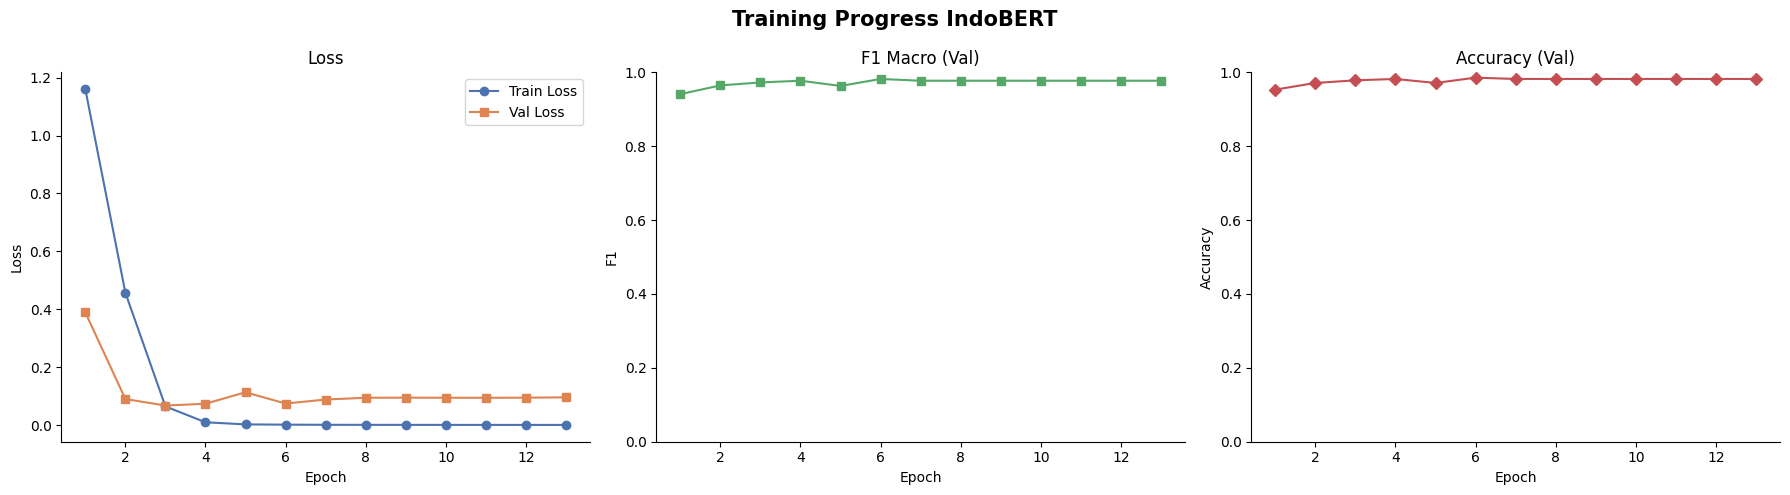

✅ Grafik training disimpan!


In [17]:
# ── Ambil log history ─────────────────────────────────────────────────────────
log_history = trainer.state.log_history

train_logs = [x for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_logs  = [x for x in log_history if 'eval_loss' in x]

epochs_train = [x['epoch'] for x in train_logs]
train_loss   = [x['loss']  for x in train_logs]

epochs_eval  = [x['epoch']        for x in eval_logs]
eval_loss    = [x['eval_loss']     for x in eval_logs]
eval_f1      = [x['eval_f1_macro'] for x in eval_logs]
eval_acc     = [x['eval_accuracy'] for x in eval_logs]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training Progress IndoBERT', fontsize=15, fontweight='bold')

# Loss
axes[0].plot(epochs_train, train_loss, 'o-', color='#4C72B0', label='Train Loss')
axes[0].plot(epochs_eval,  eval_loss,  's-', color='#DD8452', label='Val Loss')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)

# F1 Macro
axes[1].plot(epochs_eval, eval_f1, 's-', color='#55A868', marker='s')
axes[1].set_title('F1 Macro (Val)'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1')
axes[1].set_ylim(0, 1); axes[1].spines[['top','right']].set_visible(False)

# Accuracy
axes[2].plot(epochs_eval, eval_acc, 's-', color='#C44E52', marker='D')
axes[2].set_title('Accuracy (Val)'); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Accuracy')
axes[2].set_ylim(0, 1); axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik training disimpan!')

## 16. 🧪 Evaluasi di Test Set

In [18]:
print('🧪 Evaluasi model di TEST SET ...')
test_results = trainer.predict(test_dataset)

y_pred = np.argmax(test_results.predictions, axis=-1)
y_true = test_results.label_ids

print('\n' + '='*55)
print('         HASIL EVALUASI — TEST SET')
print('='*55)
print(classification_report(y_true, y_pred,
                             target_names=['Label 0', 'Label 1']))

# Ringkasan metrik
acc  = accuracy_score(y_true, y_pred)
f1m  = f1_score(y_true, y_pred, average='macro')
f1w  = f1_score(y_true, y_pred, average='weighted')
prec = precision_score(y_true, y_pred, average='macro')
rec  = recall_score(y_true, y_pred, average='macro')

print(f'  Accuracy        : {acc:.4f}')
print(f'  F1 Macro        : {f1m:.4f}')
print(f'  F1 Weighted     : {f1w:.4f}')
print(f'  Precision Macro : {prec:.4f}')
print(f'  Recall Macro    : {rec:.4f}')
print('='*55)

🧪 Evaluasi model di TEST SET ...



         HASIL EVALUASI — TEST SET
              precision    recall  f1-score   support

     Label 0       0.99      0.99      0.99       300
     Label 1       0.99      0.99      0.99       300

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600

  Accuracy        : 0.9883
  F1 Macro        : 0.9883
  F1 Weighted     : 0.9883
  Precision Macro : 0.9883
  Recall Macro    : 0.9883


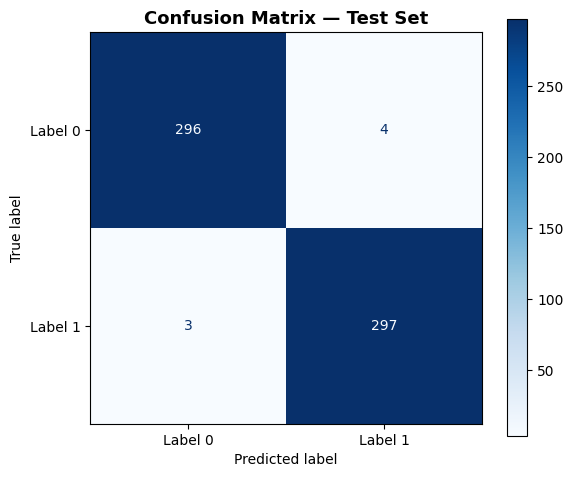

✅ Confusion matrix disimpan!


In [19]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Label 0', 'Label 1'])
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrix disimpan!')

## 17. 🔮 Inference (Prediksi Teks Baru)

In [20]:
def predict_text(text: str, model, tokenizer, device, max_len: int = MAX_LEN):
    """Prediksi label untuk satu teks baru."""
    model.eval()
    enc = tokenizer(
        text,
        max_length     = max_len,
        padding        = 'max_length',
        truncation     = True,
        return_tensors = 'pt',
    ).to(device)

    with torch.no_grad():
        outputs = model(**enc)
        probs   = torch.softmax(outputs.logits, dim=-1)
        pred    = torch.argmax(probs, dim=-1).item()

    return {
        'label'      : pred,
        'label_name' : model.config.id2label[pred],
        'confidence' : probs[0][pred].item(),
        'probs'      : {model.config.id2label[i]: probs[0][i].item()
                        for i in range(NUM_LABELS)},
    }


# ── Uji coba inferensi ────────────────────────────────────────────────────────
contoh_teks = [
    df_test['data_clean'].iloc[0],
    df_test['data_clean'].iloc[1],
]

print('🔮 Contoh Inferensi:')
for i, teks in enumerate(contoh_teks, 1):
    hasil = predict_text(teks, model, tokenizer, device)
    print(f'\n  [{i}] Teks    : {teks[:80]}...')
    print(f'       Prediksi: {hasil["label_name"]} (label {hasil["label"]})')
    print(f'       Conf     : {hasil["confidence"]*100:.2f}%')
    print(f'       Probs    : {hasil["probs"]}')

🔮 Contoh Inferensi:

  [1] Teks    : situs rtp lingtogel77 - rtp slot gacor hari ini | slot online terpercaya dan ter...
       Prediksi: Positif (label 1)
       Conf     : 99.97%
       Probs    : {'Negatif': 0.00026061866083182395, 'Positif': 0.9997393488883972}

  [2] Teks    : 'indonesia terserah' viral gara-gara corona, tandanya pasrah atau marah? ungkapa...
       Prediksi: Negatif (label 0)
       Conf     : 99.97%
       Probs    : {'Negatif': 0.9996987581253052, 'Positif': 0.0003012845991179347}


## 18. 💾 Simpan Semua Output

In [21]:
# ── Simpan prediksi test ke CSV ───────────────────────────────────────────────
df_test_result = df_test.copy()
df_test_result['pred_label'] = y_pred
df_test_result['true_label'] = y_true
df_test_result['correct']    = (y_pred == y_true)
df_test_result.to_csv(f'{OUTPUT_DIR}/test_predictions.csv', index=False)

# ── Simpan ringkasan metrik ───────────────────────────────────────────────────
metrics_summary = {
    'model'         : MODEL_NAME,
    'accuracy'      : round(acc, 4),
    'f1_macro'      : round(f1m, 4),
    'f1_weighted'   : round(f1w, 4),
    'precision_macro': round(prec, 4),
    'recall_macro'  : round(rec, 4),
    'max_len'       : MAX_LEN,
    'batch_size'    : BATCH_SIZE,
    'epochs'        : EPOCHS,
    'lr'            : LR,
}
pd.DataFrame([metrics_summary]).to_csv(f'{OUTPUT_DIR}/metrics_summary.csv', index=False)

print('💾 Semua output berhasil disimpan!')
print(f'\n📁 Isi direktori output:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, f)
    size  = os.path.getsize(fpath) / 1e6
    print(f'   {f:40s} {size:.2f} MB')

💾 Semua output berhasil disimpan!

📁 Isi direktori output:
   all_results.json                         0.00 MB
   checkpoint-120                           0.00 MB
   checkpoint-144                           0.00 MB
   checkpoint-168                           0.00 MB
   checkpoint-192                           0.00 MB
   checkpoint-216                           0.00 MB
   checkpoint-24                            0.00 MB
   checkpoint-240                           0.00 MB
   checkpoint-264                           0.00 MB
   checkpoint-288                           0.00 MB
   checkpoint-312                           0.00 MB
   checkpoint-48                            0.00 MB
   checkpoint-72                            0.00 MB
   checkpoint-96                            0.00 MB
   config.json                              0.00 MB
   confusion_matrix.png                     0.03 MB
   distribusi_label.png                     0.08 MB
   metrics_summary.csv                      0.00 MB
   mo

In [23]:
import shutil, os

# Hapus semua checkpoint KECUALI checkpoint-144 (yang terbaik)
checkpoint_dir = OUTPUT_DIR
best_checkpoint = 'checkpoint-144'

for item in os.listdir(checkpoint_dir):
    if item.startswith('checkpoint-') and item != best_checkpoint:
        full_path = os.path.join(checkpoint_dir, item)
        shutil.rmtree(full_path)
        print(f'🗑️ Dihapus: {item}')

print('\n✅ Selesai! Sisa storage:')
os.system('df -h /kaggle/working')

🗑️ Dihapus: checkpoint-264
🗑️ Dihapus: checkpoint-168
🗑️ Dihapus: checkpoint-288
🗑️ Dihapus: checkpoint-72
🗑️ Dihapus: checkpoint-96
🗑️ Dihapus: checkpoint-48
🗑️ Dihapus: checkpoint-216
🗑️ Dihapus: checkpoint-192
🗑️ Dihapus: checkpoint-312
🗑️ Dihapus: checkpoint-240
🗑️ Dihapus: checkpoint-120
🗑️ Dihapus: checkpoint-24

✅ Selesai! Sisa storage:
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  2.9G   17G  15% /kaggle/working


0

In [25]:
import zipfile, os

OUTPUT_DIR = '/kaggle/working/indobert-output'
ZIP_PATH   = '/kaggle/working/indobert_finetuned_solo.zip'

FILES_TO_ZIP = [
    'config.json',
    'model.safetensors',
    'tokenizer.json',
    'tokenizer_config.json',
]

print('📦 Membuat ZIP ...')
with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in FILES_TO_ZIP:
        full_path = os.path.join(OUTPUT_DIR, fname)
        zf.write(full_path, fname)
        print(f'   ✅ {fname}')

zip_size = os.path.getsize(ZIP_PATH) / 1e6
print(f'\n✅ ZIP selesai!')
print(f'   Lokasi : {ZIP_PATH}')
print(f'   Ukuran : {zip_size:.2f} MB')

📦 Membuat ZIP ...
   ✅ config.json
   ✅ model.safetensors
   ✅ tokenizer.json
   ✅ tokenizer_config.json

✅ ZIP selesai!
   Lokasi : /kaggle/working/indobert_finetuned_solo.zip
   Ukuran : 462.29 MB


In [27]:
import zipfile, json, os

ZIP_PATH   = '/kaggle/working/indobert_finetuned_solo.zip'
UNZIP_DIR  = '/kaggle/working/indobert_verify'

# Unzip
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    zf.extractall(UNZIP_DIR)
    print('📂 Isi zip:')
    for f in zf.namelist():
        print(f'   {f}')

📂 Isi zip:
   config.json
   model.safetensors
   tokenizer.json
   tokenizer_config.json


In [28]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model     = AutoModelForSequenceClassification.from_pretrained(UNZIP_DIR)
tokenizer = AutoTokenizer.from_pretrained(UNZIP_DIR)

print(f"✅ num_labels : {model.config.num_labels}")
print(f"✅ model_type : {model.config.model_type}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ num_labels : 2
✅ model_type : bert


In [30]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score

# ── Load model dari zip yang sudah di-unzip ────────────────────────────────────
UNZIP_DIR = '/kaggle/working/indobert_verify'

model     = AutoModelForSequenceClassification.from_pretrained(UNZIP_DIR)
tokenizer = AutoTokenizer.from_pretrained(UNZIP_DIR)

# ── Buat trainer minimal (tidak perlu training) ────────────────────────────────
trainer = Trainer(model=model)

# ── Predict pakai test_dataset yang sudah ada ─────────────────────────────────
print('🧪 Evaluasi model dari ZIP di TEST SET ...')
test_results = trainer.predict(test_dataset)
y_pred = np.argmax(test_results.predictions, axis=-1)
y_true = test_results.label_ids

print('\n' + '='*55)
print('    HASIL EVALUASI — VERIFIKASI ZIP')
print('='*55)
print(classification_report(y_true, y_pred,
                             target_names=['Label 0', 'Label 1']))
acc  = accuracy_score(y_true, y_pred)
f1m  = f1_score(y_true, y_pred, average='macro')
f1w  = f1_score(y_true, y_pred, average='weighted')
prec = precision_score(y_true, y_pred, average='macro')
rec  = recall_score(y_true, y_pred, average='macro')
print(f'  Accuracy        : {acc:.4f}')
print(f'  F1 Macro        : {f1m:.4f}')
print(f'  F1 Weighted     : {f1w:.4f}')
print(f'  Precision Macro : {prec:.4f}')
print(f'  Recall Macro    : {rec:.4f}')
print('='*55)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

🧪 Evaluasi model dari ZIP di TEST SET ...



    HASIL EVALUASI — VERIFIKASI ZIP
              precision    recall  f1-score   support

     Label 0       0.99      0.99      0.99       300
     Label 1       0.99      0.99      0.99       300

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600

  Accuracy        : 0.9883
  F1 Macro        : 0.9883
  F1 Weighted     : 0.9883
  Precision Macro : 0.9883
  Recall Macro    : 0.9883


In [23]:
# ── Klik link di bawah ini untuk download ─────────────────────────────────────
print('⬇️  Klik link di bawah untuk download:')
display(FileLink('/kaggle/working/indobert_output_all.zip',
                 result_html_prefix='📥 Download: '))

⬇️  Klik link di bawah untuk download:


/kaggle/working/indobert_output_all.zip

---
## ✅ Pipeline Selesai!

| File Output | Keterangan |
|---|---|
| `pytorch_model.bin` / `model.safetensors` | Bobot model terbaik |
| `config.json` | Konfigurasi model |
| `tokenizer_config.json` | Konfigurasi tokenizer |
| `test_predictions.csv` | Prediksi di test set |
| `metrics_summary.csv` | Ringkasan metrik |
| `training_curves.png` | Grafik training |
| `confusion_matrix.png` | Confusion matrix |
| `distribusi_label.png` | Grafik distribusi |

> **Tips:** Untuk load ulang model: `AutoModelForSequenceClassification.from_pretrained(OUTPUT_DIR)`